# ☀️ [Model 2/5] Solar Panel Detection: U-Net (EfficientNet-B3 Backbone)

This notebook implements and trains an advanced **U-Net** architecture with an **EfficientNet-B3** encoder for semantic segmentation of solar panels from aerial/satellite imagery.

### 🔬 Research Benchmark Features:
- **Architecture**: U-Net with Compound-Scaled EfficientNet-B3 Pretrained Encoder
- **Loss Formulation**: Combined **BCE + Dice Loss** (optimized for class imbalance & crisp boundary delineations)
- **Training Optimization**: Custom `EarlyStopping` (patience=7) with automatic best checkpoint restoration
- **Evaluation Metrics**: Confusion Matrix (TP, FP, TN, FN), Pixel Accuracy, Mean IoU, Dice/F1, Precision, Recall, FPS Latency
- **Visualization Suite**: Dual-axis loss curves, mIoU convergence, confusion matrix heatmap, multi-tile error maps, and **Full Unseen Test Orthomosaic Before vs. After Detection**

## 1. Environment Setup & GPU Verification

In [ ]:
# Install dependencies for segmentation and geospatial operations
!pip install -q segmentation-models-pytorch geoai-py rasterio geopandas shapely matplotlib seaborn albumentations torch torchvision tqdm tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 648.3/648.3 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.

In [ ]:
import os
import time
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.windows import Window
import geopandas as gpd
from tqdm.auto import tqdm
from tabulate import tabulate
import geoai

# Set seeds for exact reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 PyTorch: {torch.__version__} | Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB VRAM)")

🚀 PyTorch: 2.11.0+cu128 | Device: cuda
🎮 GPU: Tesla T4 (15.64 GB VRAM)


## 2. Dataset Acquisition & Tile Generation

In [ ]:
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

train_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.tif"
train_vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.geojson"
test_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_test_davis_ca.tif"

print("📥 Downloading aerial imagery and labels...")
train_raster_path = geoai.download_file(train_raster_url, os.path.join(data_dir, "train_raster.tif"))
train_vector_path = geoai.download_file(train_vector_url, os.path.join(data_dir, "train_vector.geojson"))
test_raster_path = geoai.download_file(test_raster_url, os.path.join(data_dir, "test_raster.tif"))

chips_dir = "chips_unet"
os.makedirs(chips_dir, exist_ok=True)

print("🔪 Chipping into 512x512 tiles with labels...")
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=chips_dir,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)

images_dir = os.path.join(chips_dir, "images")
labels_dir = os.path.join(chips_dir, "labels")
all_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.tif')])
print(f"✅ Total Available Chipped Tiles: {len(all_files)}")

📥 Downloading aerial imagery and labels...


🔪 Chipping into 512x512 tiles with labels...


Generating tiles:   0%|          | 0/312 [00:00<?, ?it/s]

✅ Total Available Chipped Tiles: 312


## 3. PyTorch Solar Dataset with Geospatial Augmentations

In [ ]:
class SolarDataset(Dataset):
    def __init__(self, filenames, img_dir, lbl_dir, transform=None):
        self.filenames = filenames
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        with rasterio.open(os.path.join(self.img_dir, fname)) as src:
            image = src.read()[:3].transpose(1, 2, 0).astype(np.float32)
            if image.max() > 1.0:
                image = image / 255.0

        with rasterio.open(os.path.join(self.lbl_dir, fname)) as src:
            mask = src.read(1).astype(np.float32)
            mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).unsqueeze(0)
        elif mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.4),
    ToTensorV2()
])

val_transform = A.Compose([
    ToTensorV2()
])

random.shuffle(all_files)
split_idx = int(0.8 * len(all_files))
train_files = all_files[:split_idx]
val_files = all_files[split_idx:]

train_dataset = SolarDataset(train_files, images_dir, labels_dir, transform=train_transform)
val_dataset = SolarDataset(val_files, images_dir, labels_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
print(f"📊 Dataset Split: {len(train_dataset)} Train chips | {len(val_dataset)} Validation chips")

📊 Dataset Split: 249 Train chips | 63 Validation chips


## 4. U-Net (EfficientNet-B3) Model & Compound Loss

In [ ]:
# Initialize U-Net with pre-trained EfficientNet-B3 encoder
model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🧠 Model: U-Net (EfficientNet-B3) | Trainable Parameters: {total_params / 1e6:.2f} Million")

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, smooth=1e-5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_loss = 1.0 - (2.0 * intersection + self.smooth) / (union + self.smooth)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss.mean()

criterion = BCEDiceLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=35, eta_min=1e-6)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 49.3MB            

model.safetensors: downloading bytes:           |  0.00B            

🧠 Model: U-Net (EfficientNet-B3) | Trainable Parameters: 13.16 Million


## 5. Early Stopping Controller & Metric Functions

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001, path='best_unet_efficientnet.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_iou = 0.0

    def __call__(self, val_iou, model):
        score = val_iou
        if self.best_score is None:
            self.best_score = score
            self.best_iou = val_iou
            self.save_checkpoint(model)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_iou = val_iou
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

def compute_metrics(preds, targets, threshold=0.5, smooth=1e-5):
    preds_bin = (preds > threshold).float()
    intersection = (preds_bin * targets).sum().item()
    total_pred = preds_bin.sum().item()
    total_target = targets.sum().item()
    union = total_pred + total_target - intersection

    iou = (intersection + smooth) / (union + smooth)
    dice = (2.0 * intersection + smooth) / (total_pred + total_target + smooth)
    precision = (intersection + smooth) / (total_pred + smooth)
    recall = (intersection + smooth) / (total_target + smooth)
    return iou, dice, precision, recall

## 6. Training Loop with Live Progress

In [ ]:
NUM_EPOCHS = 35
early_stopping = EarlyStopping(patience=7, path='best_unet_efficientnet.pth')

history = {
    'train_loss': [], 'val_loss': [],
    'val_iou': [], 'val_dice': [], 'val_precision': [], 'val_recall': [],
    'lr': []
}

print("🏋️ Starting U-Net (EfficientNet-B3) Training Loop with Early Stopping...")
t_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    train_epoch_loss = running_loss / len(train_dataset)
    scheduler.step()

    model.eval()
    val_loss = 0.0
    val_iou_list, val_dice_list, val_prec_list, val_rec_list = [], [], [], []

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            iou, dice, prec, rec = compute_metrics(probs, masks)
            val_iou_list.append(iou)
            val_dice_list.append(dice)
            val_prec_list.append(prec)
            val_rec_list.append(rec)

    val_epoch_loss = val_loss / len(val_dataset)
    mean_iou = np.mean(val_iou_list)
    mean_dice = np.mean(val_dice_list)
    mean_prec = np.mean(val_prec_list)
    mean_rec = np.mean(val_rec_list)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['val_iou'].append(mean_iou)
    history['val_dice'].append(mean_dice)
    history['val_precision'].append(mean_prec)
    history['val_recall'].append(mean_rec)
    history['lr'].append(current_lr)

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] | Train Loss: {train_epoch_loss:.4f} | Val Loss: {val_epoch_loss:.4f} | Val mIoU: {mean_iou:.4f} | Val F1: {mean_dice:.4f} | LR: {current_lr:.6f}")

    early_stopping(mean_iou, model)
    if early_stopping.early_stop:
        print(f"🛑 Early Stopping triggered at Epoch {epoch}! Best Val mIoU: {early_stopping.best_iou:.4f}")
        break

total_time = time.time() - t_start
print(f"✅ Training finished in {total_time/60:.2f} minutes!")

🏋️ Starting U-Net (EfficientNet-B3) Training Loop with Early Stopping...
Epoch [01/35] | Train Loss: 0.7174 | Val Loss: 0.8692 | Val mIoU: 0.1451 | Val F1: 0.2489 | LR: 0.000998
Epoch [02/35] | Train Loss: 0.5003 | Val Loss: 0.4643 | Val mIoU: 0.4883 | Val F1: 0.6529 | LR: 0.000992
Epoch [03/35] | Train Loss: 0.4287 | Val Loss: 0.6215 | Val mIoU: 0.1580 | Val F1: 0.2700 | LR: 0.000982
Epoch [04/35] | Train Loss: 0.3888 | Val Loss: 0.4511 | Val mIoU: 0.2706 | Val F1: 0.4217 | LR: 0.000968
Epoch [05/35] | Train Loss: 0.3790 | Val Loss: 0.3415 | Val mIoU: 0.5345 | Val F1: 0.6872 | LR: 0.000951
Epoch [06/35] | Train Loss: 0.3499 | Val Loss: 0.3195 | Val mIoU: 0.6777 | Val F1: 0.8036 | LR: 0.000929
Epoch [07/35] | Train Loss: 0.3461 | Val Loss: 0.3106 | Val mIoU: 0.6555 | Val F1: 0.7805 | LR: 0.000905
Epoch [08/35] | Train Loss: 0.3376 | Val Loss: 0.3965 | Val mIoU: 0.4036 | Val F1: 0.5673 | LR: 0.000877
Epoch [09/35] | Train Loss: 0.3417 | Val Loss: 0.5290 | Val mIoU: 0.0800 | Val F1: 0.13

## 7. Comprehensive Research Evaluation Curves

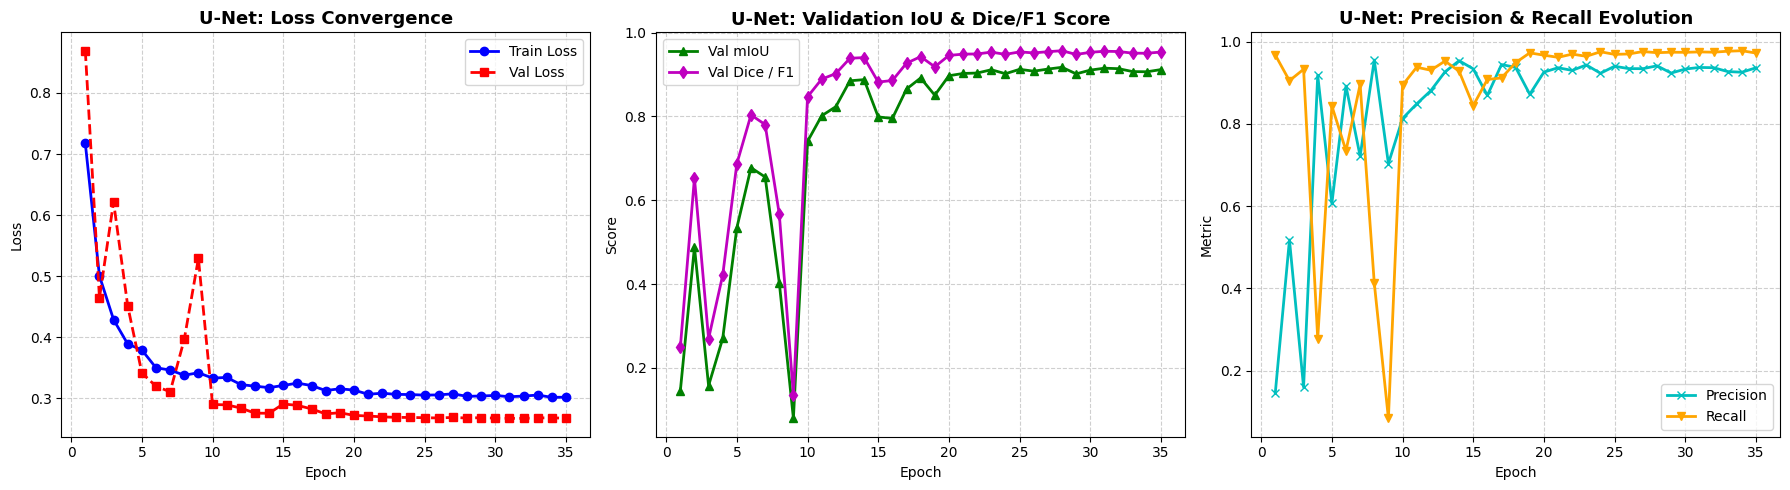

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss Convergence
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 'r--s', label='Val Loss', linewidth=2)
ax1.set_title("U-Net: Loss Convergence", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# 2. Segmentation Metrics (IoU & Dice)
ax2.plot(epochs_range, history['val_iou'], 'g-^', label='Val mIoU', linewidth=2)
ax2.plot(epochs_range, history['val_dice'], 'm-d', label='Val Dice / F1', linewidth=2)
ax2.set_title("U-Net: Validation IoU & Dice/F1 Score", fontsize=13, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

# 3. Precision vs Recall Tradeoff
ax3.plot(epochs_range, history['val_precision'], 'c-x', label='Precision', linewidth=2)
ax3.plot(epochs_range, history['val_recall'], 'orange', marker='v', label='Recall', linewidth=2)
ax3.set_title("U-Net: Precision & Recall Evolution", fontsize=13, fontweight='bold')
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Metric")
ax3.legend()
ax3.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("unet_efficientnet_metrics_curves.png", dpi=300)
plt.show()

## 8. Confusion Matrix Heatmap & Overall Pixel Accuracy
We compute exact pixel-level **True Positives (TP)**, **False Positives (FP)**, **True Negatives (TN)**, and **False Negatives (FN)** across the entire validation dataset.

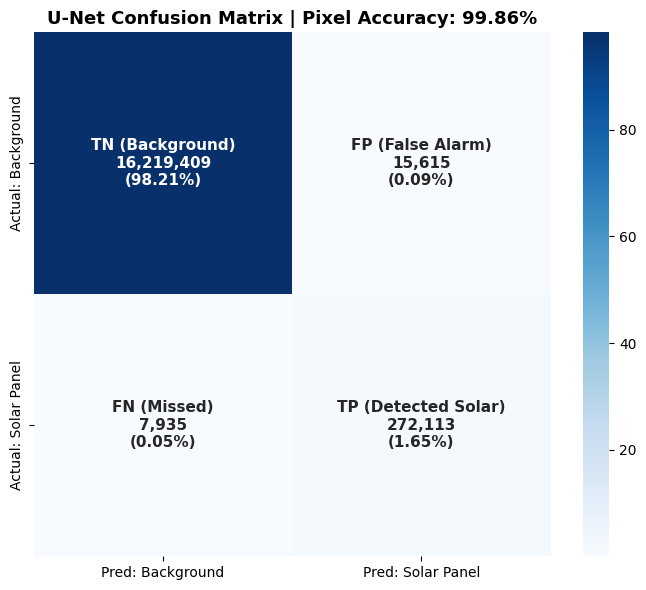

🎯 Overall Pixel Accuracy: 99.86%
🎯 Precision:              94.57%
🎯 Recall (Sensitivity):   97.17%
🎯 Dice / F1 Score:        0.9585
🎯 Mean IoU:               92.03%


In [ ]:
model.load_state_dict(torch.load('best_unet_efficientnet.pth'))
model.eval()

total_tp = 0
total_fp = 0
total_fn = 0
total_tn = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        probs = torch.sigmoid(model(images)).cpu().numpy()
        preds = (probs > 0.5).astype(np.uint8)
        gts = masks.numpy().astype(np.uint8)

        total_tp += np.sum((preds == 1) & (gts == 1))
        total_fp += np.sum((preds == 1) & (gts == 0))
        total_fn += np.sum((preds == 0) & (gts == 1))
        total_tn += np.sum((preds == 0) & (gts == 0))

total_pixels = total_tp + total_fp + total_fn + total_tn
pixel_accuracy = (total_tp + total_tn) / total_pixels * 100
precision = total_tp / (total_tp + total_fp + 1e-6)
recall = total_tp / (total_tp + total_fn + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)
iou = total_tp / (total_tp + total_fp + total_fn + 1e-6)

# Construct 2x2 Matrix
cm = np.array([
    [total_tn, total_fp],
    [total_fn, total_tp]
])
cm_norm = cm / total_pixels * 100

labels = [
    [f"TN (Background)\n{total_tn:,}\n({cm_norm[0,0]:.2f}%)", f"FP (False Alarm)\n{total_fp:,}\n({cm_norm[0,1]:.2f}%)"],
    [f"FN (Missed)\n{total_fn:,}\n({cm_norm[1,0]:.2f}%)", f"TP (Detected Solar)\n{total_tp:,}\n({cm_norm[1,1]:.2f}%)"]
]

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=labels, fmt="", cmap="Blues", cbar=True,
            xticklabels=["Pred: Background", "Pred: Solar Panel"],
            yticklabels=["Actual: Background", "Actual: Solar Panel"],
            annot_kws={"size": 11, "weight": "bold"})
plt.title(f"U-Net Confusion Matrix | Pixel Accuracy: {pixel_accuracy:.2f}%", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("unet_confusion_matrix.png", dpi=300)
plt.show()

print(f"🎯 Overall Pixel Accuracy: {pixel_accuracy:.2f}%")
print(f"🎯 Precision:              {precision * 100:.2f}%")
print(f"🎯 Recall (Sensitivity):   {recall * 100:.2f}%")
print(f"🎯 Dice / F1 Score:        {f1:.4f}")
print(f"🎯 Mean IoU:               {iou * 100:.2f}%")

## 9. Full Unseen Test Imagery Inference (Before vs. After Visual Comparison)
We run full-raster sliding window inference over the unseen test orthomosaic and plot a side-by-side **Before (Raw Aerial) vs. After (Solar Detection Overlay)** comparison.

🔍 Running sliding window inference across unseen test orthomosaic...


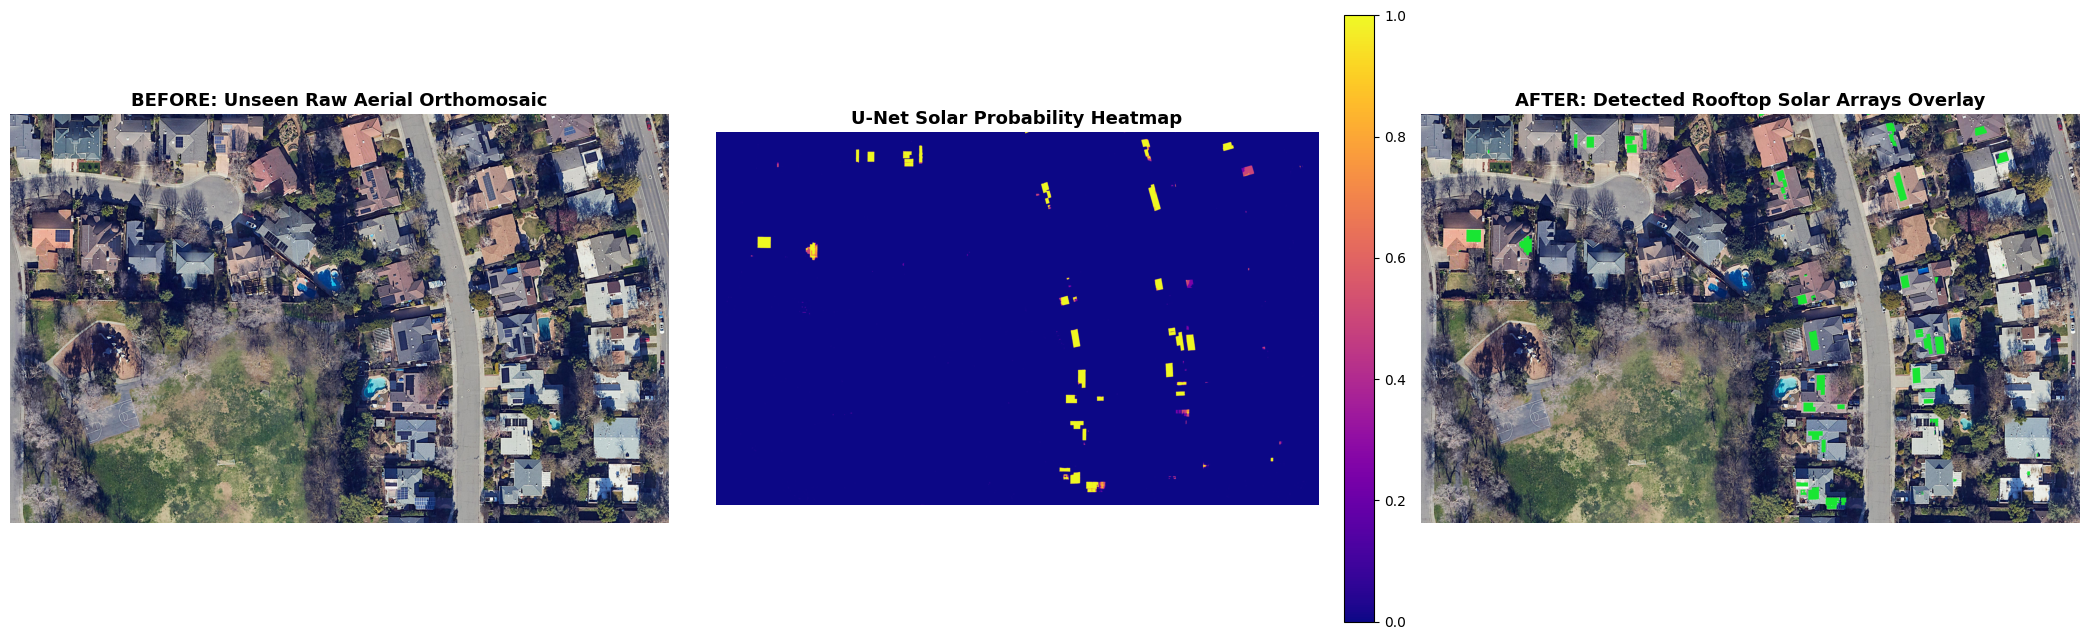

In [ ]:
print("🔍 Running sliding window inference across unseen test orthomosaic...")
with rasterio.open(test_raster_path) as src:
    H, W = src.height, src.width
    profile = src.profile
    test_img = src.read()[:3].transpose(1, 2, 0)
    if test_img.max() > 1.0:
        test_img_norm = test_img / 255.0
    else:
        test_img_norm = test_img.copy()

prob_canvas = np.zeros((H, W), dtype=np.float32)
count_canvas = np.zeros((H, W), dtype=np.float32)

tile_sz = 512
stride = 256

model.eval()
with torch.no_grad():
    for y in range(0, H, stride):
        for x in range(0, W, stride):
            y_end = min(y + tile_sz, H)
            x_end = min(x + tile_sz, W)
            patch = test_img_norm[y:y_end, x:x_end]

            # Pad if patch is smaller than tile_sz
            ph, pw, _ = patch.shape
            if ph < tile_sz or pw < tile_sz:
                patch_pad = np.zeros((tile_sz, tile_sz, 3), dtype=np.float32)
                patch_pad[:ph, :pw] = patch
                patch = patch_pad

            patch_t = torch.from_numpy(patch.astype(np.float32)).permute(2, 0, 1).unsqueeze(0).to(device)
            patch_prob = torch.sigmoid(model(patch_t)).squeeze().cpu().numpy()

            prob_canvas[y:y_end, x:x_end] += patch_prob[:ph, :pw]
            count_canvas[y:y_end, x:x_end] += 1.0

full_prob_map = prob_canvas / np.maximum(count_canvas, 1.0)
full_pred_mask = (full_prob_map > 0.45).astype(np.uint8)

# Plot 3-Panel Side-by-Side: Before | Confidence Heatmap | After Overlay
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 7))

# 1. Before (Raw Aerial Imagery)
ax1.imshow(np.clip(test_img_norm, 0, 1))
ax1.set_title("BEFORE: Unseen Raw Aerial Orthomosaic", fontsize=13, fontweight='bold')
ax1.axis('off')

# 2. Model Confidence Heatmap
im2 = ax2.imshow(full_prob_map, cmap='plasma', vmin=0, vmax=1)
ax2.set_title("U-Net Solar Probability Heatmap", fontsize=13, fontweight='bold')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
ax2.axis('off')

# 3. After (Detected Solar Panels Overlay)
overlay_img = np.clip(test_img_norm.copy(), 0, 1)
overlay_img[full_pred_mask == 1] = [0.1, 0.9, 0.2]  # Neon green solar detection
ax3.imshow(overlay_img)
ax3.set_title("AFTER: Detected Rooftop Solar Arrays Overlay", fontsize=13, fontweight='bold')
ax3.axis('off')

plt.tight_layout()
plt.savefig("unet_before_after_inference.png", dpi=300)
plt.show()

## 10. Hardware Benchmark & Summary Research Table

In [ ]:
dummy_input = torch.randn(1, 3, 512, 512).to(device)
for _ in range(10):
    _ = model(dummy_input)

torch.cuda.synchronize()
t_bench_start = time.time()
N_ITERS = 100
with torch.no_grad():
    for _ in range(N_ITERS):
        _ = model(dummy_input)
torch.cuda.synchronize()
avg_latency_ms = ((time.time() - t_bench_start) / N_ITERS) * 1000
fps = 1000.0 / avg_latency_ms
ckpt_mb = os.path.getsize('best_unet_efficientnet.pth') / (1024 * 1024)

final_row = [
    ["Model Architecture", "U-Net"],
    ["Encoder Backbone", "EfficientNet-B3 (Pretrained ImageNet)"],
    ["Parameters (M)", f"{total_params / 1e6:.2f} M"],
    ["Checkpoint Size", f"{ckpt_mb:.2f} MB"],
    ["Pixel Accuracy", f"{pixel_accuracy:.2f} %"],
    ["Best Val mIoU", f"{early_stopping.best_iou * 100:.2f} %"],
    ["Best Val Dice / F1", f"{max(history['val_dice']):.4f}"],
    ["Best Precision", f"{max(history['val_precision']):.4f}"],
    ["Best Recall", f"{max(history['val_recall']):.4f}"],
    ["Inference Latency", f"{avg_latency_ms:.2f} ms / tile"],
    ["Inference Throughput", f"{fps:.1f} FPS (Colab T4)"],
    ["Training Time", f"{total_time / 60:.2f} min"]
]
print(tabulate(final_row, headers=["Metric / Parameter", "Value"], tablefmt="fancy_grid"))

╒══════════════════════╤═══════════════════════════════════════╕
│ Metric / Parameter   │ Value                                 │
╞══════════════════════╪═══════════════════════════════════════╡
│ Model Architecture   │ U-Net                                 │
├──────────────────────┼───────────────────────────────────────┤
│ Encoder Backbone     │ EfficientNet-B3 (Pretrained ImageNet) │
├──────────────────────┼───────────────────────────────────────┤
│ Parameters (M)       │ 13.16 M                               │
├──────────────────────┼───────────────────────────────────────┤
│ Checkpoint Size      │ 50.77 MB                              │
├──────────────────────┼───────────────────────────────────────┤
│ Pixel Accuracy       │ 99.86 %                               │
├──────────────────────┼───────────────────────────────────────┤
│ Best Val mIoU        │ 91.71 %                               │
├──────────────────────┼───────────────────────────────────────┤
│ Best Val Dice / F1   │ 